# BÀI TẬP: E-COMMERCE DATA (ONLINE RETAIL)
**Nguồn:** kaggle.com/datasets/carrie1/ecommerce-data (541,909 dòng)


## Setup

In [58]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv'

df = pd.read_csv(csv_path, encoding='ISO-8859-1', on_bad_lines='skip')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [59]:
# TODO
print(df.size)
df.info()

4335272
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


## A.2. Missing values & Duplicate data

In [60]:
# TODO
print(df.isnull().sum())
print("duplicate:",df.duplicated().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
duplicate: 5268


## A.3. Invalid values

In [61]:
# TODO
dl =df['Quantity']<0
print("số lượng âm: ",dl.sum())
dk=df['UnitPrice']<0
print("giá âm: ",dk.sum())

số lượng âm:  10624
giá âm:  2


## A.4. Create a new column
Làm sạch dữ liệu (loại Quantity<=0, UnitPrice<=0), tạo cột `Sales` = Quantity * UnitPrice.

In [62]:
# TODO
df.head()
df=df[(df['Quantity']>0) & (df['UnitPrice']>0)]
df['Sales']=df['Quantity'] *df['UnitPrice']

---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [63]:
# TODO
for col in ['Quantity', 'UnitPrice', 'Sales']:
    print(f"{col}: mean={df[col].mean():.2f}, median={df[col].median():.2f}, mode={df[col].mode()[0]:.2f}")

Quantity: mean=10.54, median=3.00, mode=1.00
UnitPrice: mean=3.91, median=2.08, mode=1.25
Sales: mean=20.12, median=9.90, mode=15.00


## Group 2 — Dispersion

In [64]:
# TODO
for col in ['Quantity', 'UnitPrice', 'Sales']:
    std, rng = df[col].std(), df[col].max()-df[col].min()
    iqr = df[col].quantile(0.75) - df[col].quantile(0.25)
    print(f"{col}: std={std:.2f}, range={rng:.2f}, IQR={iqr:.2f}")

Quantity: std=155.52, range=80994.00, IQR=9.00
UnitPrice: std=35.92, range=13541.33, IQR=2.88
Sales: std=270.36, range=168469.60, IQR=13.95


## Group 3 — Location and Shape

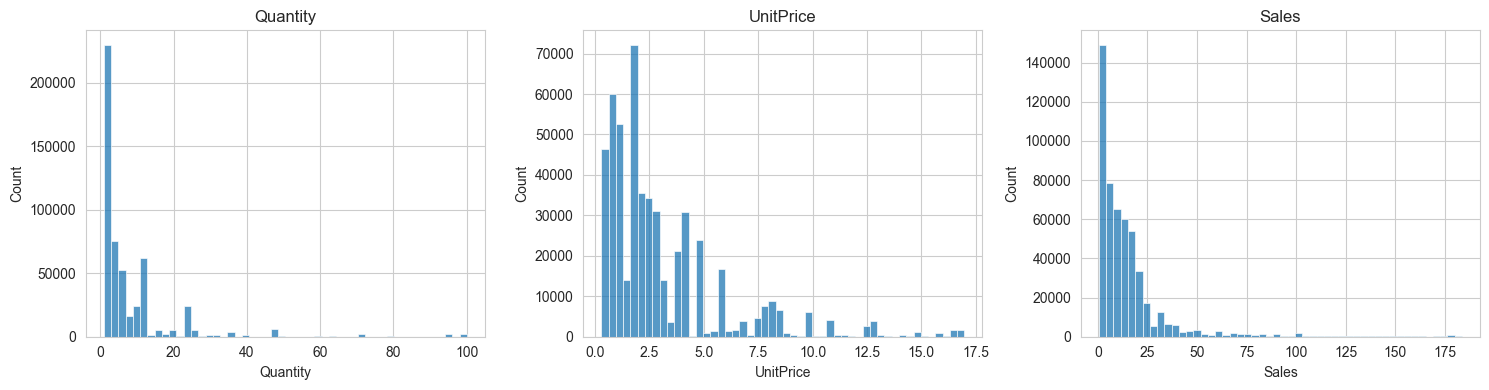

In [65]:
# TODO
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, ['Quantity', 'UnitPrice', 'Sales']):
    lower, upper = df[col].quantile(0.01), df[col].quantile(0.99)
    data_clip = df[col][(df[col] >= lower) & (df[col] <= upper)]
    sns.histplot(data_clip, kde=False, bins=50, ax=ax)  
    ax.set_title(col)
plt.tight_layout(); plt.show()

---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Quốc gia nào đóng góp doanh thu cao nhất, chiếm bao nhiêu % tổng doanh thu?

Country
United Kingdom    9025222.084
Netherlands        285446.340
EIRE               283453.960
Germany            228867.140
France             209715.110
Australia          138521.310
Spain               61577.110
Switzerland         57089.900
Belgium             41196.340
Sweden              38378.330
Name: Sales, dtype: float64
% top 1: 84.61131522893568


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'United Kingdom'),
  Text(1, 0, 'Netherlands'),
  Text(2, 0, 'EIRE'),
  Text(3, 0, 'Germany'),
  Text(4, 0, 'France'),
  Text(5, 0, 'Australia'),
  Text(6, 0, 'Spain'),
  Text(7, 0, 'Switzerland'),
  Text(8, 0, 'Belgium'),
  Text(9, 0, 'Sweden')])

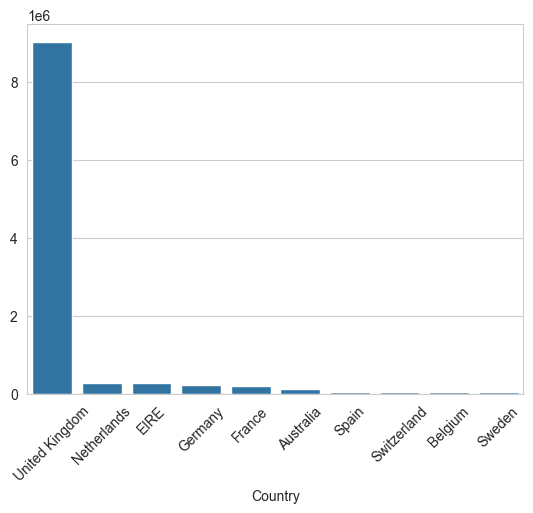

In [66]:
# TODO
country_sales = df.groupby('Country')['Sales'].sum().sort_values(ascending=False)
print(country_sales.head(10))
print('% top 1:', country_sales.iloc[0] / country_sales.sum() * 100)

sns.barplot(x=country_sales.head(10).index, y=country_sales.head(10).values)
plt.xticks(rotation=45)

## Câu hỏi 2: Sản phẩm nào bán chạy nhất theo doanh thu?

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174484.74
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106292.77
PARTY BUNTING                          99504.33
JUMBO BAG RED RETROSPOT                94340.05
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
Manual                                 78112.82
POSTAGE                                78101.88
RABBIT NIGHT LIGHT                     66964.99
Name: Sales, dtype: float64


<Axes: ylabel='Description'>

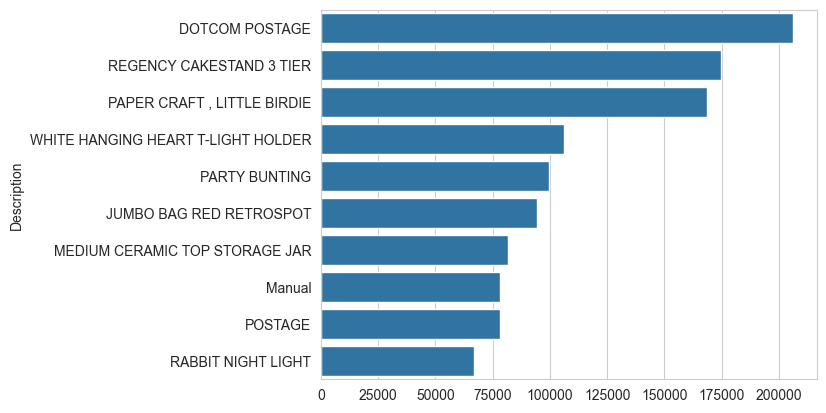

In [67]:
# TODO
top_products = df.groupby('Description')['Sales'].sum().sort_values(ascending=False)
print(top_products.head(10))
sns.barplot(x=top_products.head(10).values, y=top_products.head(10).index)

## Câu hỏi 3: Doanh số có tính mùa vụ theo tháng không?

Month
2010-12     823746.140
2011-01     691364.560
2011-02     523631.890
2011-03     717639.360
2011-04     537808.621
2011-05     770536.020
2011-06     761739.900
2011-07     719221.191
2011-08     759138.380
2011-09    1058590.172
2011-10    1154979.300
2011-11    1509496.330
2011-12     638792.680
Freq: M, Name: Sales, dtype: float64


Text(0, 0.5, 'Sales')

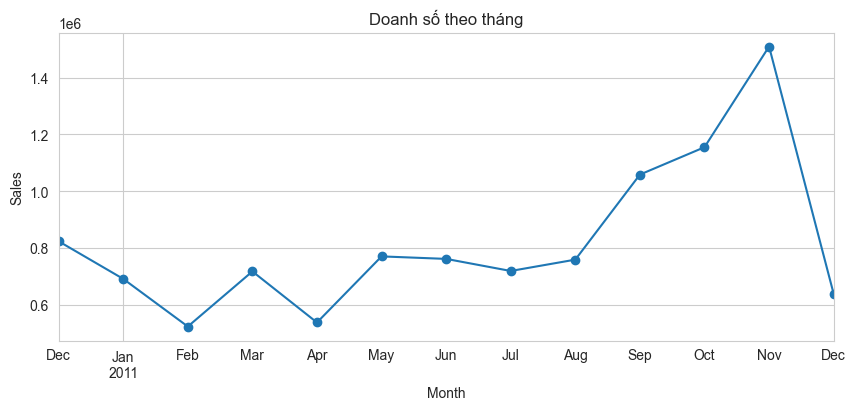

In [68]:
# TODO
df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Sales'].sum()
print(monthly_sales)

monthly_sales.plot(kind='line', figsize=(10,4), marker='o')
plt.title('Doanh số theo tháng')
plt.ylabel('Sales')

## Câu hỏi 4: Giá trị đơn hàng trung bình (Average Order Value) khác nhau thế nào giữa các quốc gia?

Country
Singapore      3039.898571
Netherlands    3036.663191
Australia      2430.198421
Japan          1969.282632
Lebanon        1693.880000
Hong Kong      1426.527273
Brazil         1143.600000
Sweden         1066.064722
Switzerland    1057.220370
Denmark        1053.074444
dtype: float64


C:\Users\ASUS TUF\AppData\Local\Temp\ipykernel_3252\1741380331.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  aov = df.groupby('Country').apply(lambda x: x['Sales'].sum() / x['InvoiceNo'].nunique())


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Singapore'),
  Text(1, 0, 'Netherlands'),
  Text(2, 0, 'Australia'),
  Text(3, 0, 'Japan'),
  Text(4, 0, 'Lebanon'),
  Text(5, 0, 'Hong Kong'),
  Text(6, 0, 'Brazil'),
  Text(7, 0, 'Sweden'),
  Text(8, 0, 'Switzerland'),
  Text(9, 0, 'Denmark')])

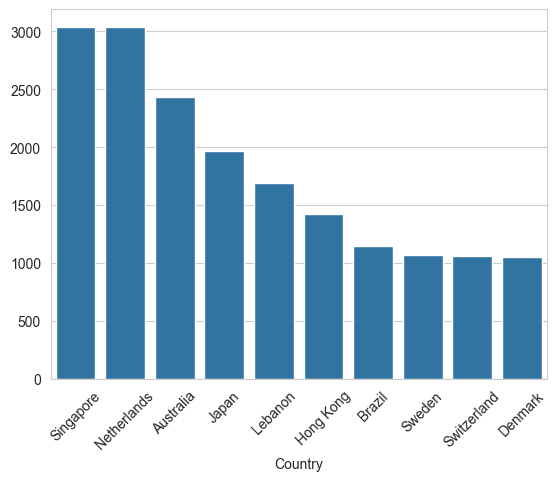

In [69]:
# TODO
aov = df.groupby('Country').apply(lambda x: x['Sales'].sum() / x['InvoiceNo'].nunique())
aov = aov.sort_values(ascending=False)
print(aov.head(10))
sns.barplot(x=aov.head(10).index, y=aov.head(10).values)
plt.xticks(rotation=45)

## Câu hỏi 5: Tỷ lệ giao dịch có dấu hiệu trả hàng/hủy (Quantity âm ở dữ liệu gốc) khác nhau thế nào giữa các quốc gia?

Country
Australia          0.0
Austria            0.0
Bahrain            0.0
Belgium            0.0
Brazil             0.0
Canada             0.0
Channel Islands    0.0
Cyprus             0.0
Czech Republic     0.0
Denmark            0.0
dtype: float64


<Axes: xlabel='Country'>

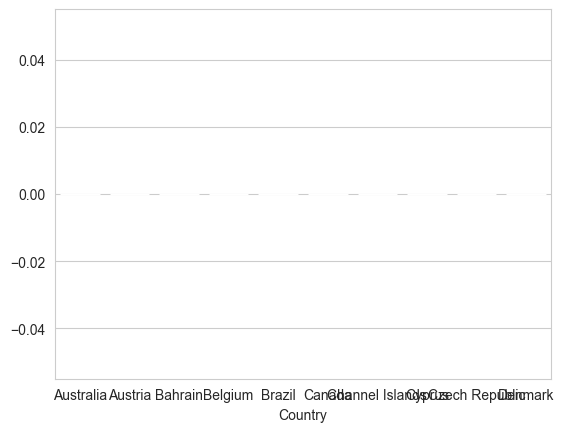

In [71]:
# TODO
df_original = df.copy() 
df = df[(df['Quantity']>0) & (df['UnitPrice']>0)]
df['Sales'] = df['Quantity'] * df['UnitPrice']
return_rate = df_original.groupby('Country', group_keys=False).apply(
    lambda x: (x['Quantity'] < 0).sum() / len(x) * 100,
    include_groups=False  
).sort_values(ascending=False)
print(return_rate.head(10))
sns.barplot(x=return_rate.head(10).index, y=return_rate.head(10).values)

## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể.

Dữ liệu có hơn 540,000 dòng nhưng khá nhiều dòng có Quantity/UnitPrice âm hoặc bằng 0 (giao dịch hủy/lỗi), cần lọc bỏ trước khi phân tích doanh thu. Doanh số (Sales) lệch phải rất mạnh do có các đơn hàng số lượng lớn xen lẫn đơn lẻ. Vương quốc Anh chiếm phần lớn doanh thu vì đây là thị trường chính của công ty. Doanh số có xu hướng tăng rõ vào các tháng cuối năm, cho thấy yếu tố mùa vụ (mua sắm dịp lễ). Tỷ lệ trả hàng/hủy khác nhau đáng kể giữa các quốc gia, đây là điểm cần công ty lưu ý về chất lượng đơn hàng ở từng thị trường.